In [1]:
import torch as tc
import torch.nn as nn
import math as mt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = tc.zeros(max_len, d_model)
        
        position = tc.arange(0,max_len,dtype=tc.float).unsqueeze(1)
        div_term = tc.exp(tc.arange(0,d_model,2).float()*(-mt.log(10000.0) / d_model))
        
        pe[:, 0::2] = tc.sin(position * div_term)
        pe[:, 1::2] = tc.cos(position * div_term)
        self.register_buffer("pe",pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [3]:
class Attention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size = x.size(0)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        Q = Q.view(batch_size,-1,self.num_heads,self.head_dim).transpose(1, 2)
        K = K.view(batch_size,-1,self.num_heads,self.head_dim).transpose(1, 2)
        V = V.view(batch_size,-1,self.num_heads,self.head_dim).transpose(1, 2)
        
        scores = tc.matmul(Q,K.transpose(-2, -1)) / mt.sqrt(self.head_dim)

        attention = tc.softmax(scores,dim=-1)
        self.attention_weights = attention
        out = tc.matmul(attention,V)
        out = out.transpose(1,2).contiguous()
        out = out.view(batch_size,-1,self.d_model)

        return self.fc(out)

In [4]:
class Forward(nn.Module):

    def __init__(self, d_model, ff_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, ff_dim),nn.ReLU(),nn.Linear(ff_dim, d_model))

    def forward(self, x):
        return self.net(x)

In [5]:
class Transformer(nn.Module):

    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()

        self.attn = Attention(d_model,num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = Forward(d_model,ff_dim)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x

In [6]:
class Ranker(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.d_model = 64
        self.embedding = nn.Linear(1,self.d_model)
        self.pos_encoding = PositionalEncoding(self.d_model,max_len=10)

        self.encoder1 = Transformer(d_model=64,num_heads=4,ff_dim=128)
        self.encoder2 = Transformer(d_model=64,num_heads=4,ff_dim=128)
        self.classifier = nn.Linear(64,10)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.classifier(x)
        return x

In [7]:
model = Ranker()
model.load_state_dict(tc.load("best_transformer_ranker.pth",map_location="cpu"))
model.eval()

Ranker(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding()
  (encoder1): Transformer(
    (attn): Attention(
      (Wq): Linear(in_features=64, out_features=64, bias=True)
      (Wk): Linear(in_features=64, out_features=64, bias=True)
      (Wv): Linear(in_features=64, out_features=64, bias=True)
      (fc): Linear(in_features=64, out_features=64, bias=True)
    )
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ff): Forward(
      (net): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=64, bias=True)
      )
    )
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (encoder2): Transformer(
    (attn): Attention(
      (Wq): Linear(in_features=64, out_features=64, bias=True)
      (Wk): Linear(in_features=64, out_features=64, bias=True)
      (Wv): Linear(in_features=64, out_features=64, bias=Tru

In [9]:
numbers = list(map(float,input("Enter 10 numbers separated by spaces: ").split()))

In [10]:
x = tc.tensor([numbers],dtype=tc.float32)
with tc.no_grad():
    logits = model(x)
    ranks = logits.argmax(dim=-1)

print("Input:")
print(numbers)
print()
print("Predicted Ranks:")
print(ranks.squeeze().tolist())

Input:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]

Predicted Ranks:
[6, 5, 5, 5, 5, 5, 5, 5, 5]


C:\Users\tilak\AppData\Local\Temp\ipykernel_28484\867196375.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


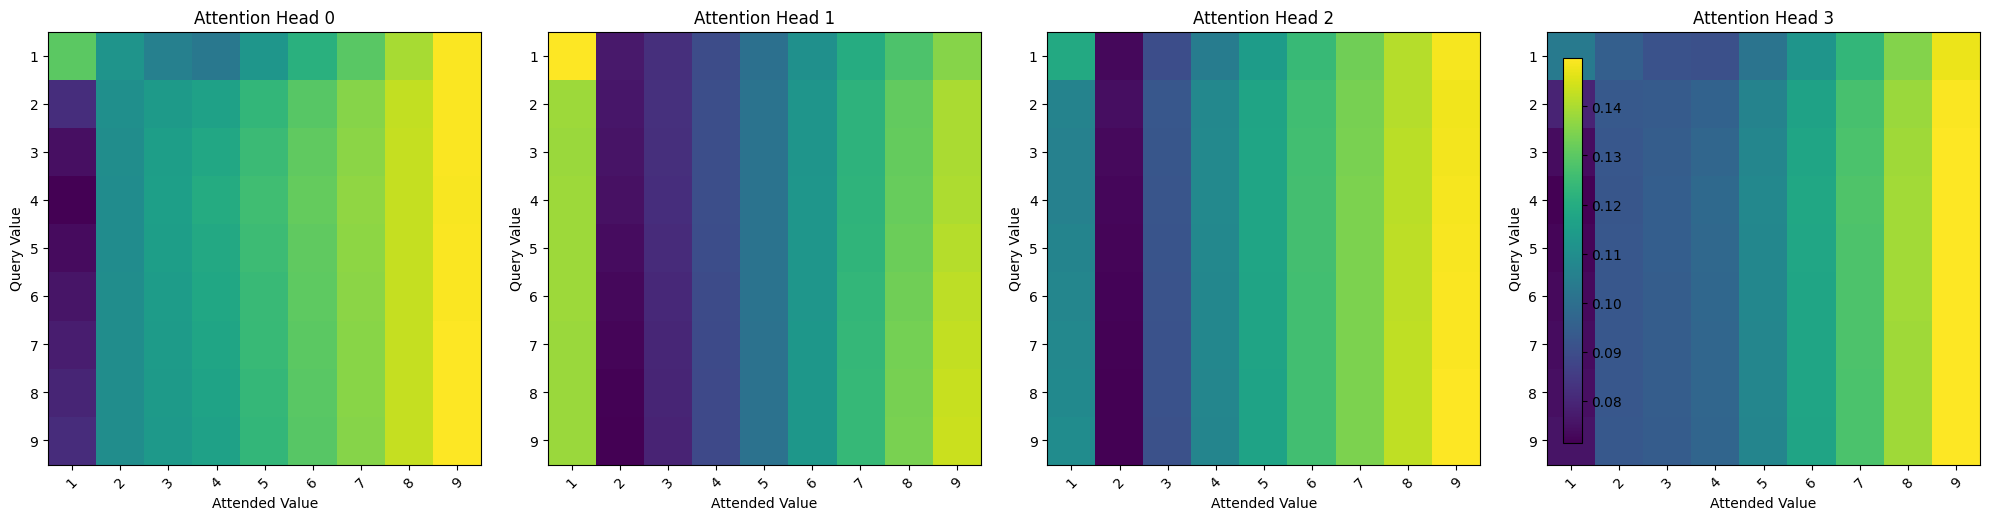

Input Sequence:
[1, 2, 3, 4, 5, 6, 7, 8, 9]

Predicted Ranks:
[6, 5, 5, 5, 5, 5, 5, 5, 5]


In [12]:
with tc.no_grad():
    logits = model(x)

attn = model.encoder2.attn.attention_weights

values = x[0].int().tolist()
preds = logits[0].argmax(dim=-1).tolist()

num_heads = attn.shape[1]
fig, axes = plt.subplots(1,num_heads,figsize=(5 * num_heads, 5))

if num_heads == 1:
    axes = [axes]

for head in range(num_heads):
    heatmap = attn[0, head].detach().cpu().numpy()
    im = axes[head].imshow(heatmap,cmap="viridis")
    axes[head].set_title(f"Attention Head {head}")

    axes[head].set_xticks(range(len(values)))
    axes[head].set_yticks(range(len(values)))

    axes[head].set_xticklabels(values,rotation=45)
    axes[head].set_yticklabels(values)
    axes[head].set_xlabel("Attended Value")

    axes[head].set_ylabel("Query Value")

fig.colorbar(im,ax=axes)

plt.tight_layout()
plt.show()

print("Input Sequence:")
print(values)

print()

print("Predicted Ranks:")
print(preds)